In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, DecisionTreeRegressor
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, r2_score, mean_squared_error

# 1
 Cгенерируйте данные для задачи классификации на три класса при помощи sklearn.datasets.make_blobs, содержащие два признака и 100 наблюдений. Визуализируйте их на диаграмме рассеяния.

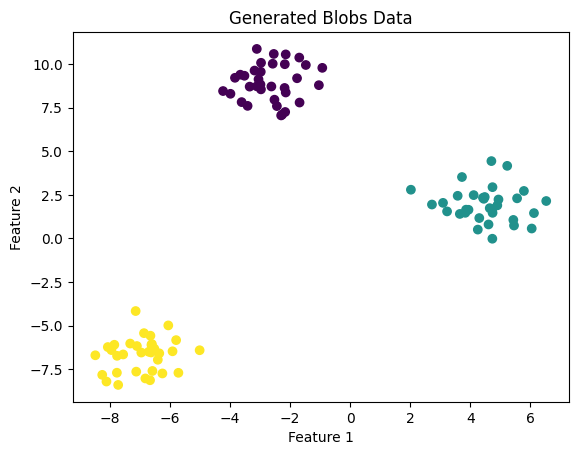

In [2]:
data = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)
X, y = data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Generated Blobs Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# 2
Обучите модель классификационного решающего дерева sklearn.svm.DecisionTreeClassifier глубины 4 и критерием entropy.


In [3]:
model = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
model.fit(X, y) 

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 3
Визуализируйте соответствующий граф дерева решений.


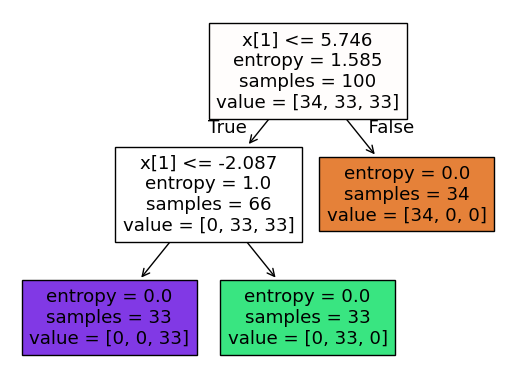

In [5]:
plot_tree(model, filled=True)
plt.show()

# 4
Визуализируйте полученные разделяющие области.


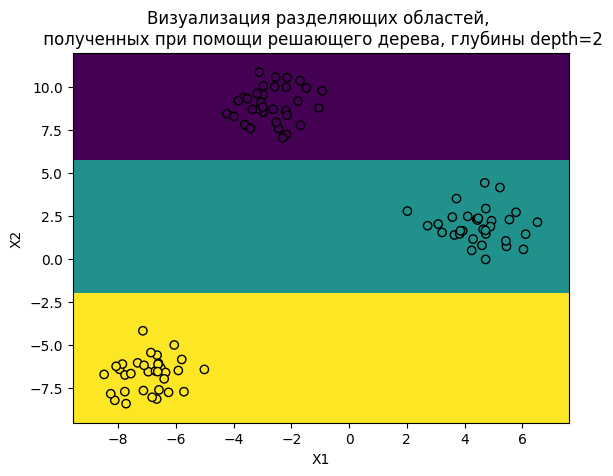

In [6]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = model.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(model.get_depth()))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# 5
Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.


In [7]:
y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred, average='weighted')
cm = confusion_matrix(y, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
print("Confusion matrix:")
print(cm)

new_obs = X.mean(axis=0).reshape(1, -1)
pred = model.predict(new_obs)
proba = model.predict_proba(new_obs)

print("\nNew observation (mean of X):", new_obs)
print("Predicted class:", int(pred[0]))
print("Predicted probabilities:", proba[0])

Accuracy: 1.0000
Weighted F1-score: 1.0000
Confusion matrix:
[[34  0  0]
 [ 0 33  0]
 [ 0  0 33]]

New observation (mean of X): [[-1.7162792   1.47485077]]
Predicted class: 1
Predicted probabilities: [0. 1. 0.]


# 6
Cгенерируйте данные для задачи регрессии, содержащие один признак и 100 наблюдений, как случайный шум некоторой функции. Визуализируйте их на диаграмме рассеяния.

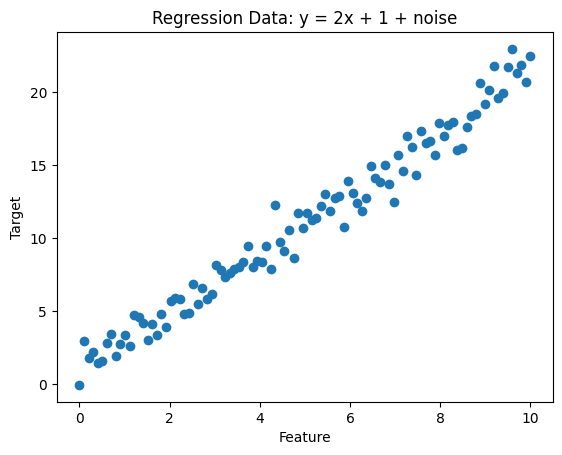

In [8]:
X_reg = np.linspace(0, 10, 100).reshape(-1, 1)
y_reg = 2 * X_reg.ravel() + 1 + np.random.normal(0, 1, 100)
plt.scatter(X_reg, y_reg)
plt.title("Regression Data: y = 2x + 1 + noise")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()

# 7
Обучите модель регрессионного решающего дерева sklearn.svm.DecisionTreeRegressor глубиной 3.


R2 (train): 0.9727
MSE (train): 0.9938


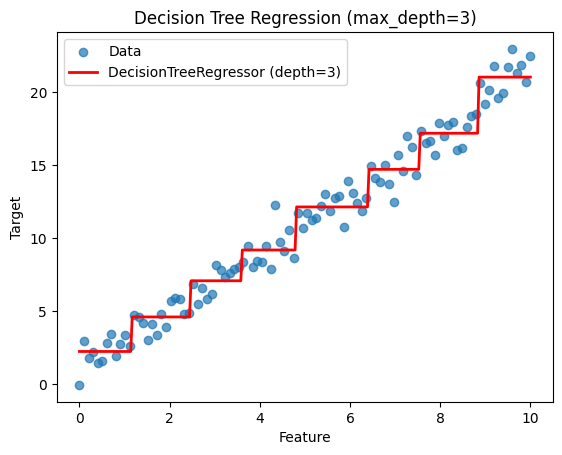

In [9]:
reg_model = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_model.fit(X_reg, y_reg)

y_reg_pred_train = reg_model.predict(X_reg)
r2 = r2_score(y_reg, y_reg_pred_train)
mse = mean_squared_error(y_reg, y_reg_pred_train)
print(f"R2 (train): {r2:.4f}")
print(f"MSE (train): {mse:.4f}")

X_reg_grid = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)
y_reg_pred_grid = reg_model.predict(X_reg_grid)

plt.scatter(X_reg, y_reg, alpha=0.7, label="Data")
plt.plot(X_reg_grid, y_reg_pred_grid, color="red", linewidth=2, label="DecisionTreeRegressor (depth=3)")
plt.title("Decision Tree Regression (max_depth=3)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

# 8 
Визуализируйте соответствующий граф дерева решений.


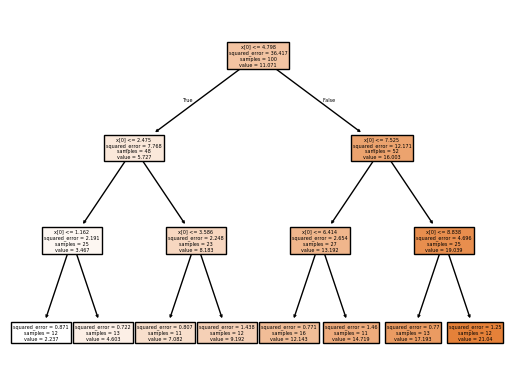

In [10]:
plot_tree(reg_model, filled=True)
plt.show()

# 9
Визуализируйте получившуюся кусочную линию регрессии.


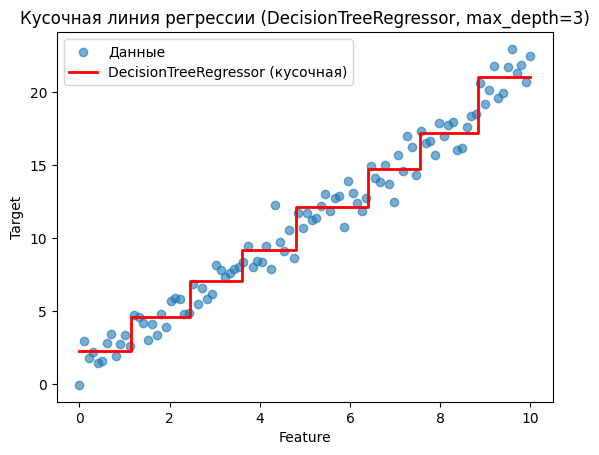

In [11]:
plt.scatter(X_reg, y_reg, alpha=0.6, label="Данные")
plt.step(X_reg_grid.ravel(), y_reg_pred_grid, where='mid', color='red', linewidth=2, label="DecisionTreeRegressor (кусочная)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Кусочная линия регрессии (DecisionTreeRegressor, max_depth=3)")
plt.legend()
plt.show()

# 10
Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.


In [12]:
y_reg_pred = reg_model.predict(X_reg)
r2 = r2_score(y_reg, y_reg_pred)
mse = mean_squared_error(y_reg, y_reg_pred)

print(f"R2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

new_obs_reg = X_reg.mean(axis=0).reshape(1, -1)
pred_reg = reg_model.predict(new_obs_reg)

print(f"\nNew observation (mean of X_reg): {new_obs_reg}")
print(f"Predicted value: {pred_reg[0]}")

R2: 0.9727
MSE: 0.9938

New observation (mean of X_reg): [[5.]]
Predicted value: 12.142539792724248
